# Crossmatch: JDA Low-res Spectra × COSMOS-Web F150W cutouts

Match `jda_spectra_low.h5` (19 513 PRISM spectra) against  
`f150w_A*.h5 / f150w_B*.h5` image cutout files.

**Output** `jda_cosmos_matched.h5`:
- `jda/`   — all JDA columns (`wave`, `flux`, `z_best`, `sn50`, `grade`, …)
- `image/` — full rows from image cutout h5 (`image` 128×128, `seg` 128×128, all catalog fields)

In [ ]:
import h5py
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

JDA_H5  = Path('/raven/u/yacheng/projects/ssl_outthere/images/JDA/jda_spectra_low.h5')
IMG_DIR = Path('/raven/u/yacheng/projects/ssl_outthere/images/jwst/f150w')
OUT_DIR = Path('/raven/u/yacheng/projects/ssl_outthere/images/cosmosf150w_jda_low')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_SEP_ARCSEC = 0.3

## 1. Load JDA spectra (all columns)

In [52]:
with h5py.File(JDA_H5, 'r') as f:
    jda_keys = list(f.keys())
    jda = {k: f[k][:] for k in jda_keys}

jda['ra']  = jda['ra'].astype(np.float64)
jda['dec'] = jda['dec'].astype(np.float64)
n_jda = len(jda['ra'])

print(f'JDA spectra : {n_jda:,}')
print(f'keys        : {jda_keys}')
print(f'RA  range   : {jda["ra"].min():.2f} – {jda["ra"].max():.2f} deg')
print(f'Dec range   : {jda["dec"].min():.2f} – {jda["dec"].max():.2f} deg')

JDA spectra : 19,513
keys        : ['dec', 'flux', 'grade', 'objid', 'phot_f150w_tot_1', 'ra', 'sn50', 'srcid', 'wave', 'z_best']
RA  range   : 3.45 – 330.73 deg
Dec range   : -67.22 – 70.28 deg


## 2. Build position index from all f150w cutout h5 files

In [53]:
img_files = sorted(IMG_DIR.glob('f150w_*.h5'))
print(f'Found {len(img_files)} image h5 files')

all_ra, all_dec     = [], []
all_file_idx        = []
all_local_idx       = []
img_keys            = None

for fi, path in enumerate(img_files):
    with h5py.File(path, 'r') as f:
        ra  = f['ra'][:].astype(np.float64)
        dec = f['dec'][:].astype(np.float64)
        n   = len(ra)
        if img_keys is None:
            img_keys = list(f.keys())
    all_ra.append(ra)
    all_dec.append(dec)
    all_file_idx.append(np.full(n, fi, dtype=np.int32))
    all_local_idx.append(np.arange(n, dtype=np.int32))
    print(f'  {path.name}: {n:,}')

all_ra        = np.concatenate(all_ra)
all_dec       = np.concatenate(all_dec)
all_file_idx  = np.concatenate(all_file_idx)
all_local_idx = np.concatenate(all_local_idx)

print(f'\nTotal image catalog : {len(all_ra):,} objects')
print(f'Image h5 keys       : {img_keys}')

Found 20 image h5 files
  f150w_A1.h5: 31,359
  f150w_A10.h5: 29,617
  f150w_A2.h5: 33,022
  f150w_A3.h5: 32,996
  f150w_A4.h5: 32,220
  f150w_A5.h5: 26,141
  f150w_A6.h5: 33,155
  f150w_A7.h5: 33,920
  f150w_A8.h5: 32,117
  f150w_A9.h5: 31,424
  f150w_B1.h5: 31,224
  f150w_B10.h5: 28,646
  f150w_B2.h5: 31,936
  f150w_B3.h5: 31,758
  f150w_B4.h5: 34,151
  f150w_B5.h5: 27,478
  f150w_B6.h5: 34,316
  f150w_B7.h5: 35,690
  f150w_B8.h5: 35,341
  f150w_B9.h5: 34,639

Total image catalog : 641,150 objects
Image h5 keys       : ['a_image', 'age_minchi2', 'axis_ratio', 'axis_ratio_err', 'b_image', 'chi2_max', 'dec', 'delta_f150w', 'flux_aper_f150w', 'flux_auto_f150w', 'flux_err_aper_f150w', 'flux_err_auto_f150w', 'id', 'id_specz_khostovan25', 'image', 'mass_minchi2', 'ml_morph_tag', 'morph_flag_f150w', 'ra', 'radius_sersic', 'radius_sersic_err', 'seg', 'segment-id', 'sersic', 'sersic_err', 'sfr_minchi2', 'snr_f150w', 'theta_image', 'theta_world', 'tile', 'x_image', 'y_image']


## 3. Crossmatch JDA ↔ image catalog

In [54]:
jda_coords = SkyCoord(ra=jda['ra'] * u.deg, dec=jda['dec'] * u.deg)
img_coords = SkyCoord(ra=all_ra    * u.deg, dec=all_dec    * u.deg)

idx_img, sep, _ = jda_coords.match_to_catalog_sky(img_coords)
sep_arcsec      = sep.to(u.arcsec).value

mask    = sep_arcsec <= MAX_SEP_ARCSEC
n_match = mask.sum()
print(f'Matched (sep ≤ {MAX_SEP_ARCSEC}"): {n_match:,} / {n_jda:,}  ({100*n_match/n_jda:.1f}%)')
print(f'Median sep (matched)           : {np.median(sep_arcsec[mask]):.3f} arcsec')

Matched (sep ≤ 0.1"): 1,772 / 19,513  (9.1%)
Median sep (matched)           : 0.029 arcsec


## 4. Separation distribution

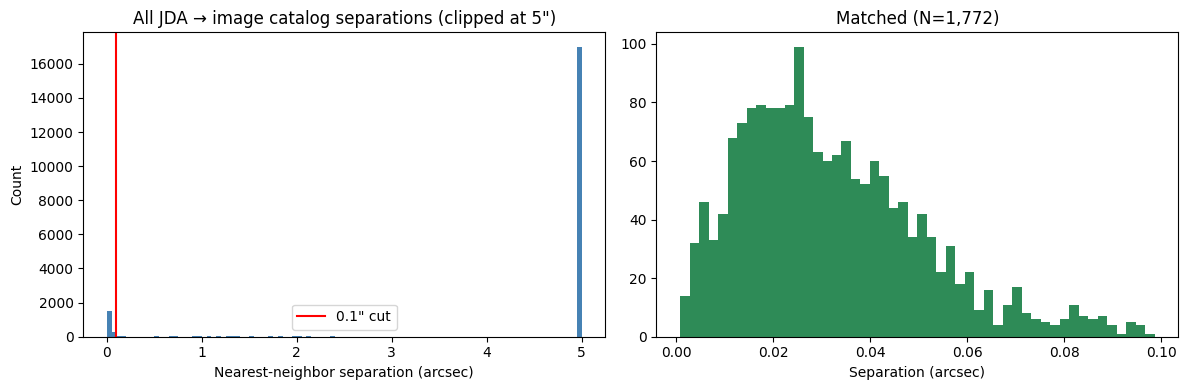

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(np.clip(sep_arcsec, 0, 5), bins=100, color='steelblue', edgecolor='none')
ax.axvline(MAX_SEP_ARCSEC, color='red', lw=1.5, label=f'{MAX_SEP_ARCSEC}" cut')
ax.set_xlabel('Nearest-neighbor separation (arcsec)')
ax.set_ylabel('Count')
ax.set_title('All JDA → image catalog separations (clipped at 5")')
ax.legend()

ax = axes[1]
ax.hist(sep_arcsec[mask], bins=50, color='seagreen', edgecolor='none')
ax.set_xlabel('Separation (arcsec)')
ax.set_title(f'Matched (N={n_match:,})')

plt.tight_layout()
plt.savefig(OUT_DIR / 'separation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Matched sample overview

In [56]:
jda_idx           = np.where(mask)[0]
img_glob_idx      = idx_img[mask]
matched_file_idx  = all_file_idx[img_glob_idx]
matched_local_idx = all_local_idx[img_glob_idx]
sep_matched       = sep_arcsec[mask]

z  = jda['z_best'][jda_idx]
sn = jda['sn50'][jda_idx]
print(f'Matched pairs : {n_match:,}')
print(f'z_best : median={np.nanmedian(z):.2f}, range=[{np.nanmin(z):.2f}, {np.nanmax(z):.2f}]')
print(f'sn50   : median={np.nanmedian(sn):.1f}, range=[{np.nanmin(sn):.1f}, {np.nanmax(sn):.1f}]')

unique_files = np.unique(matched_file_idx)
print(f'\nFiles with matches:')
for fi in unique_files:
    cnt = (matched_file_idx == fi).sum()
    print(f'  {img_files[fi].name}: {cnt:,}')

Matched pairs : 1,772
z_best : median=1.98, range=[-1.00, 9.81]
sn50   : median=3.7, range=[-0.3, 407.9]

Files with matches:
  f150w_A3.h5: 91
  f150w_B2.h5: 98
  f150w_B3.h5: 161
  f150w_B7.h5: 377
  f150w_B8.h5: 1,045


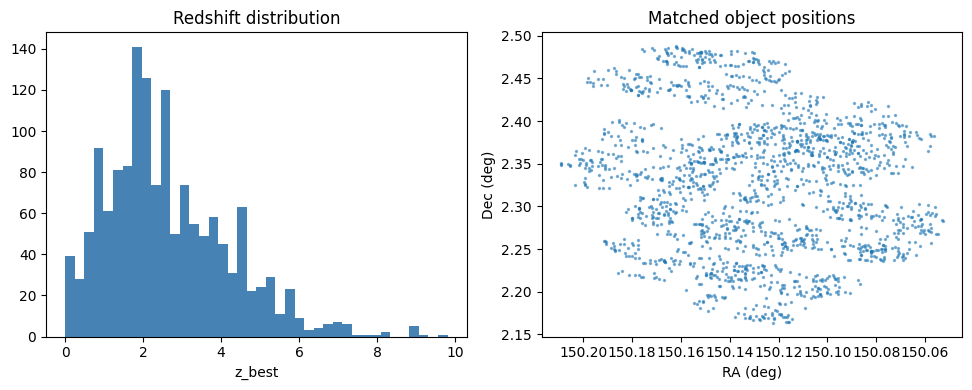

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(z[np.isfinite(z) & (z >= 0)], bins=40, color='steelblue', edgecolor='none')
axes[0].set_xlabel('z_best')
axes[0].set_title('Redshift distribution')

axes[1].scatter(all_ra[img_glob_idx], all_dec[img_glob_idx],
                s=2, alpha=0.5, rasterized=True)
axes[1].set_xlabel('RA (deg)')
axes[1].set_ylabel('Dec (deg)')
axes[1].set_title('Matched object positions')
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(OUT_DIR / 'matched_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save matched catalog

For each matched object write:
- **`jda/`**  — all JDA columns (spectra `wave`/`flux`, `z_best`, `sn50`, `grade`, `ra`, `dec`, …)
- **`image/`** — full row from cutout h5 (`image` 128×128, `seg` 128×128, all catalog fields)

In [58]:
def _write(grp, name, arr):
    """Write array to h5py group; encode string dtypes as bytes."""
    if arr.dtype.kind in ('U', 'O'):
        arr = arr.astype('S')
    grp.create_dataset(name, data=arr)

out_path = OUT_DIR / 'jda_cosmos_matched.h5'

# Get image/seg shapes and all key dtypes from first file
with h5py.File(img_files[0], 'r') as f0:
    img_shape = f0['image'].shape[1:]   # (128, 128)
    seg_shape = f0['seg'].shape[1:]     # (128, 128)
    img_dtype = f0['image'].dtype
    seg_dtype = f0['seg'].dtype
    # shapes and dtypes for all other keys
    other_meta = {k: (f0[k].shape[1:], f0[k].dtype)
                  for k in img_keys if k not in ('image', 'seg')}

print(f'image : {img_shape}  {img_dtype}')
print(f'seg   : {seg_shape}  {seg_dtype}')
print(f'other keys: {list(other_meta.keys())}')

image : (128, 128)  float32
seg   : (128, 128)  uint8
other keys: ['a_image', 'age_minchi2', 'axis_ratio', 'axis_ratio_err', 'b_image', 'chi2_max', 'dec', 'delta_f150w', 'flux_aper_f150w', 'flux_auto_f150w', 'flux_err_aper_f150w', 'flux_err_auto_f150w', 'id', 'id_specz_khostovan25', 'mass_minchi2', 'ml_morph_tag', 'morph_flag_f150w', 'ra', 'radius_sersic', 'radius_sersic_err', 'segment-id', 'sersic', 'sersic_err', 'sfr_minchi2', 'snr_f150w', 'theta_image', 'theta_world', 'tile', 'x_image', 'y_image']


In [59]:
# Group matched indices by source file for efficient sequential reads
file_groups = defaultdict(list)   # file_idx → list of (output_pos, local_row)
for out_pos, (fi, li) in enumerate(zip(matched_file_idx, matched_local_idx)):
    file_groups[fi].append((out_pos, li))

# Numpy buffers — avoids h5py write-order constraints
img_buf = np.empty((n_match, *img_shape), dtype=img_dtype)
seg_buf = np.empty((n_match, *seg_shape), dtype=seg_dtype)
bufs    = {k: np.empty((n_match,) + shape, dtype=dt)
           for k, (shape, dt) in other_meta.items()}

print('Reading image data...')
for fi, entries in sorted(file_groups.items()):
    out_pos  = np.array([e[0] for e in entries])
    loc_rows = np.array([e[1] for e in entries])

    # h5py requires strictly increasing, unique indices.
    # np.unique returns sorted unique values; inverse maps back to original order.
    uniq_rows, inverse = np.unique(loc_rows, return_inverse=True)

    print(f'  {img_files[fi].name}: {len(loc_rows):,} objects '
          f'({len(uniq_rows):,} unique rows)', end='', flush=True)

    with h5py.File(img_files[fi], 'r') as src:
        # Read unique rows (sorted → h5py happy), scatter via inverse
        img_buf[out_pos] = src['image'][uniq_rows][inverse]
        seg_buf[out_pos] = src['seg'][uniq_rows][inverse]
        for k in bufs:
            if k in src:
                bufs[k][out_pos] = src[k][uniq_rows][inverse]
    print(' ✓')

with h5py.File(out_path, 'w') as out:

    # ── JDA group: all columns ────────────────────────────────────────────
    jda_grp = out.create_group('jda')
    jda_grp.create_dataset('jda_row', data=jda_idx)
    for k in jda_keys:
        _write(jda_grp, k, jda[k][jda_idx])

    # ── Image group ───────────────────────────────────────────────────────
    img_grp = out.create_group('image')
    img_grp.create_dataset('src_file',  data=np.array(
        [img_files[i].name for i in matched_file_idx], dtype='S'))
    img_grp.create_dataset('file_idx',  data=matched_file_idx)
    img_grp.create_dataset('local_row', data=matched_local_idx)
    img_grp.create_dataset('image', data=img_buf)
    img_grp.create_dataset('seg',   data=seg_buf)
    for k, buf in bufs.items():
        _write(img_grp, k, buf)

    # ── Match metadata ────────────────────────────────────────────────────
    out.create_dataset('sep_arcsec', data=sep_matched)
    out.attrs['max_sep_arcsec'] = MAX_SEP_ARCSEC
    out.attrs['n_jda_total']    = n_jda
    out.attrs['n_img_total']    = len(all_ra)
    out.attrs['n_matched']      = n_match
    out.attrs['jda_source']     = str(JDA_H5)
    out.attrs['img_dir']        = str(IMG_DIR)

print(f'\nSaved → {out_path}')

Reading image data...
  f150w_A3.h5: 91 objects (90 unique rows) ✓
  f150w_B2.h5: 98 objects (97 unique rows) ✓
  f150w_B3.h5: 161 objects (159 unique rows) ✓
  f150w_B7.h5: 377 objects (364 unique rows) ✓
  f150w_B8.h5: 1,045 objects (1,020 unique rows) ✓

Saved → /raven/u/yacheng/projects/ssl_outthere/images/cosmosf150w_jda_low/jda_cosmos_matched.h5


## 7. Verify output

In [60]:
with h5py.File(out_path, 'r') as f:
    print('=== jda_cosmos_matched.h5 ===')
    for grp in ['jda', 'image']:
        print(f'  {grp}/')
        for k, v in f[grp].items():
            print(f'    {k:35s}: {str(v.shape):25s} {v.dtype}')
    print(f'  sep_arcsec: {f["sep_arcsec"].shape}')
    print()
    for k, v in f.attrs.items():
        print(f'  {k} = {v}')

=== jda_cosmos_matched.h5 ===
  jda/
    dec                                : (1772,)                   float64
    flux                               : (1772, 56)                float32
    grade                              : (1772,)                   float32
    jda_row                            : (1772,)                   int64
    objid                              : (1772,)                   int64
    phot_f150w_tot_1                   : (1772,)                   float32
    ra                                 : (1772,)                   float64
    sn50                               : (1772,)                   float32
    srcid                              : (1772,)                   int64
    wave                               : (1772, 56)                float32
    z_best                             : (1772,)                   float32
  image/
    a_image                            : (1772,)                   float64
    age_minchi2                        : (1772,)            